In [1]:
!pip install vidaug --quiet

# === Cell 1: Setup & Metadata ===

In [2]:
import os
import cv2
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from vidaug import augmentors as va

# --- Paths ---
primary_video_dir = "/kaggle/input/datasets/risangbaskoro/wlasl-processed/videos"
backup_video_dir = "/kaggle/input/datasets/sttaseen/wlasl2000-resized/wlasl-complete/videos"
json_path = "/kaggle/input/datasets/risangbaskoro/wlasl-processed/nslt_100.json"
class_list_path = "/kaggle/input/datasets/risangbaskoro/wlasl-processed/wlasl_class_list.txt"
raw_frame_dir = "/kaggle/working/frames_rgb"
os.makedirs(raw_frame_dir, exist_ok=True)

# === INSERTED ===
samuel_video_dir = "/kaggle/input/datasets/meng2026kimpinde/asl-kimpinde/ASL-Kimpinde set/videos"
samuel_metadata_path = "/kaggle/input/datasets/meng2026kimpinde/asl-kimpinde/ASL-Kimpinde set/metadata.csv"

# --- Parameters ---
IMG_SIZE = 64
FPS_TARGETS = [10, 15, 30, 50]
NUM_FRAMES = 24 # Ablation study with 8, 16

# --- Load class list ---
idx_to_label = {}
label_to_idx = {}
with open(class_list_path, "r") as f:
    for line in f:
        idx, label = line.strip().split("\t")
        idx = int(idx)
        idx_to_label[idx] = label
        label_to_idx[label] = idx

# --- Load WLASL JSON metadata ---
with open(json_path, "r") as f:
    data = json.load(f)

metadata = {}
for video_id, info in data.items():
    label_idx = info["action"][0]
    label = idx_to_label.get(label_idx, f"unknown_{label_idx}")
    metadata[video_id] = {
        "label": label,
        "primary_path": os.path.join(primary_video_dir, f"{video_id}.mp4"),
        "backup_path": os.path.join(backup_video_dir, f"{video_id}.mp4"),
    }

df_wlasl = pd.DataFrame.from_dict(metadata, orient="index").reset_index().rename(columns={"index": "video_id"})

# === INSERTED: Load Samuel metadata ===
df_samuel = pd.read_csv(samuel_metadata_path)
samuel_records = []
next_idx = max(label_to_idx.values()) + 1

for _, row in df_samuel.iterrows():
    label = row["label"]
    if label not in label_to_idx:
        label_to_idx[label] = next_idx
        idx_to_label[next_idx] = label
        next_idx += 1
    samuel_records.append({
        "video_id": row["filename"].replace(".avi", ""),
        "label": label,
        "primary_path": os.path.join(samuel_video_dir, row["filename"]),
        "backup_path": os.path.join(samuel_video_dir, row["filename"]),
    })

df_samuel = pd.DataFrame(samuel_records)

# === Merge both datasets ===
df = pd.concat([df_wlasl, df_samuel], ignore_index=True)

# === Cell 2: Validation & Balancing ===

In [3]:
valid_videos = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    cap = cv2.VideoCapture(row["primary_path"])
    if not cap.isOpened():
        cap.release()
        cap = cv2.VideoCapture(row["backup_path"])
    path = row["primary_path"] if cap.isOpened() else row["backup_path"]

    if cap.isOpened():
        fps = cap.get(cv2.CAP_PROP_FPS)
        ret, _ = cap.read()
        if ret and fps:
            valid_videos.append({**row, "video_path": path, "fps": fps})
    cap.release()

valid_df = pd.DataFrame(valid_videos)

# --- Downsample Classes with >25 Valid Videos ---
balanced_videos = []
grouped = valid_df.groupby("label")
for label, group in grouped:
    if len(group) >= 18:
        sample_size = min(len(group), 25)
        sampled = group.sample(n=sample_size, random_state=42)
        balanced_videos.append(sampled)

filtered_df = pd.concat(balanced_videos).reset_index(drop=True)
print(f"Balanced dataset contains {len(filtered_df)} videos across {filtered_df['label'].nunique()} classes.")


100%|██████████| 2288/2288 [00:43<00:00, 53.02it/s]


Balanced dataset contains 2181 videos across 100 classes.


# === Cell 3: Augmentation & Keyframe Extraction ===

In [4]:
augment_seq = va.Sequential([
    va.RandomRotate(degrees=10),
    va.GaussianBlur(1.0)
])

def simulate_fps(frames, fps_orig, fps_target):
    step = max(1, int(round(fps_orig / fps_target)))
    return frames[::step]

def hybrid_subsample_pad(frames, target_len=NUM_FRAMES):
    num = len(frames)
    if num >= target_len:
        indices = np.linspace(0, num - 1, target_len).astype(int)
        return np.array([frames[i] for i in indices], dtype=np.float32)
    else:
        pad = [frames[-1]] * (target_len - num)
        return np.array(frames + pad, dtype=np.float32)

for _, row in tqdm(filtered_df.iterrows(), total=len(filtered_df)):
    label_dir = os.path.join(raw_frame_dir, row["label"])
    os.makedirs(label_dir, exist_ok=True)
    video_id = row["video_id"]
    fps_orig = row["fps"]
    cap = cv2.VideoCapture(row["video_path"])

    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = np.expand_dims(frame, axis=-1).astype(np.float32) / 255.0
        frames.append(frame)
    cap.release()

    if not frames:
        continue

    frames_aug = augment_seq(frames)

    variant_map = {
        f"{video_id}_orig_{int(fps_orig)}fps.npy": hybrid_subsample_pad(frames),
        f"{video_id}_aug_{int(fps_orig)}fps.npy": hybrid_subsample_pad(frames_aug),
    }

    for fps_t in FPS_TARGETS:
        variant_map[f"{video_id}_orig_{fps_t}fps.npy"] = hybrid_subsample_pad(simulate_fps(frames, fps_orig, fps_t))
        variant_map[f"{video_id}_aug_{fps_t}fps.npy"] = hybrid_subsample_pad(simulate_fps(frames_aug, fps_orig, fps_t))

    for name, data in variant_map.items():
        np.save(os.path.join(label_dir, name), data.astype(np.float32))

100%|██████████| 2181/2181 [02:44<00:00, 13.26it/s]


# === Cell 4: Load Dataset & Split ===

In [5]:
from sklearn.model_selection import train_test_split

all_data, all_labels = [], []
available_labels = os.listdir(raw_frame_dir)
label_to_idx = {label: idx for label, idx in label_to_idx.items() if label in available_labels}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

for label in label_to_idx:
    label_path = os.path.join(raw_frame_dir, label)
    for fname in os.listdir(label_path):
        if fname.endswith(".npy"):
            arr = np.load(os.path.join(label_path, fname))
            all_data.append(arr)
            all_labels.append(label_to_idx[label])

all_data = np.array(all_data, dtype=np.float32)
all_labels = np.array(all_labels)


# --- Stratified Split ---
X_train, X_temp, y_train, y_temp = train_test_split(
    all_data, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, stratify=y_temp, random_state=42
)

# --- Save Splits ---
np.save(os.path.join(raw_frame_dir, "X_train.npy"), X_train)
np.save(os.path.join(raw_frame_dir, "y_train.npy"), y_train)
np.save(os.path.join(raw_frame_dir, "X_val.npy"), X_val)
np.save(os.path.join(raw_frame_dir, "y_val.npy"), y_val)
np.save(os.path.join(raw_frame_dir, "X_test.npy"), X_test)
np.save(os.path.join(raw_frame_dir, "y_test.npy"), y_test)

with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "w") as f:
    json.dump(label_to_idx, f)



# === Cell 5: Visualize Distribution ===

/tmp/ipykernel_55/2201034345.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Label", y="Count", palette=color)
/tmp/ipykernel_55/2201034345.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Label", y="Count", palette=color)
/tmp/ipykernel_55/2201034345.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Label", y="Count", palette=color)
/tmp/ipykernel_55/2201034345.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

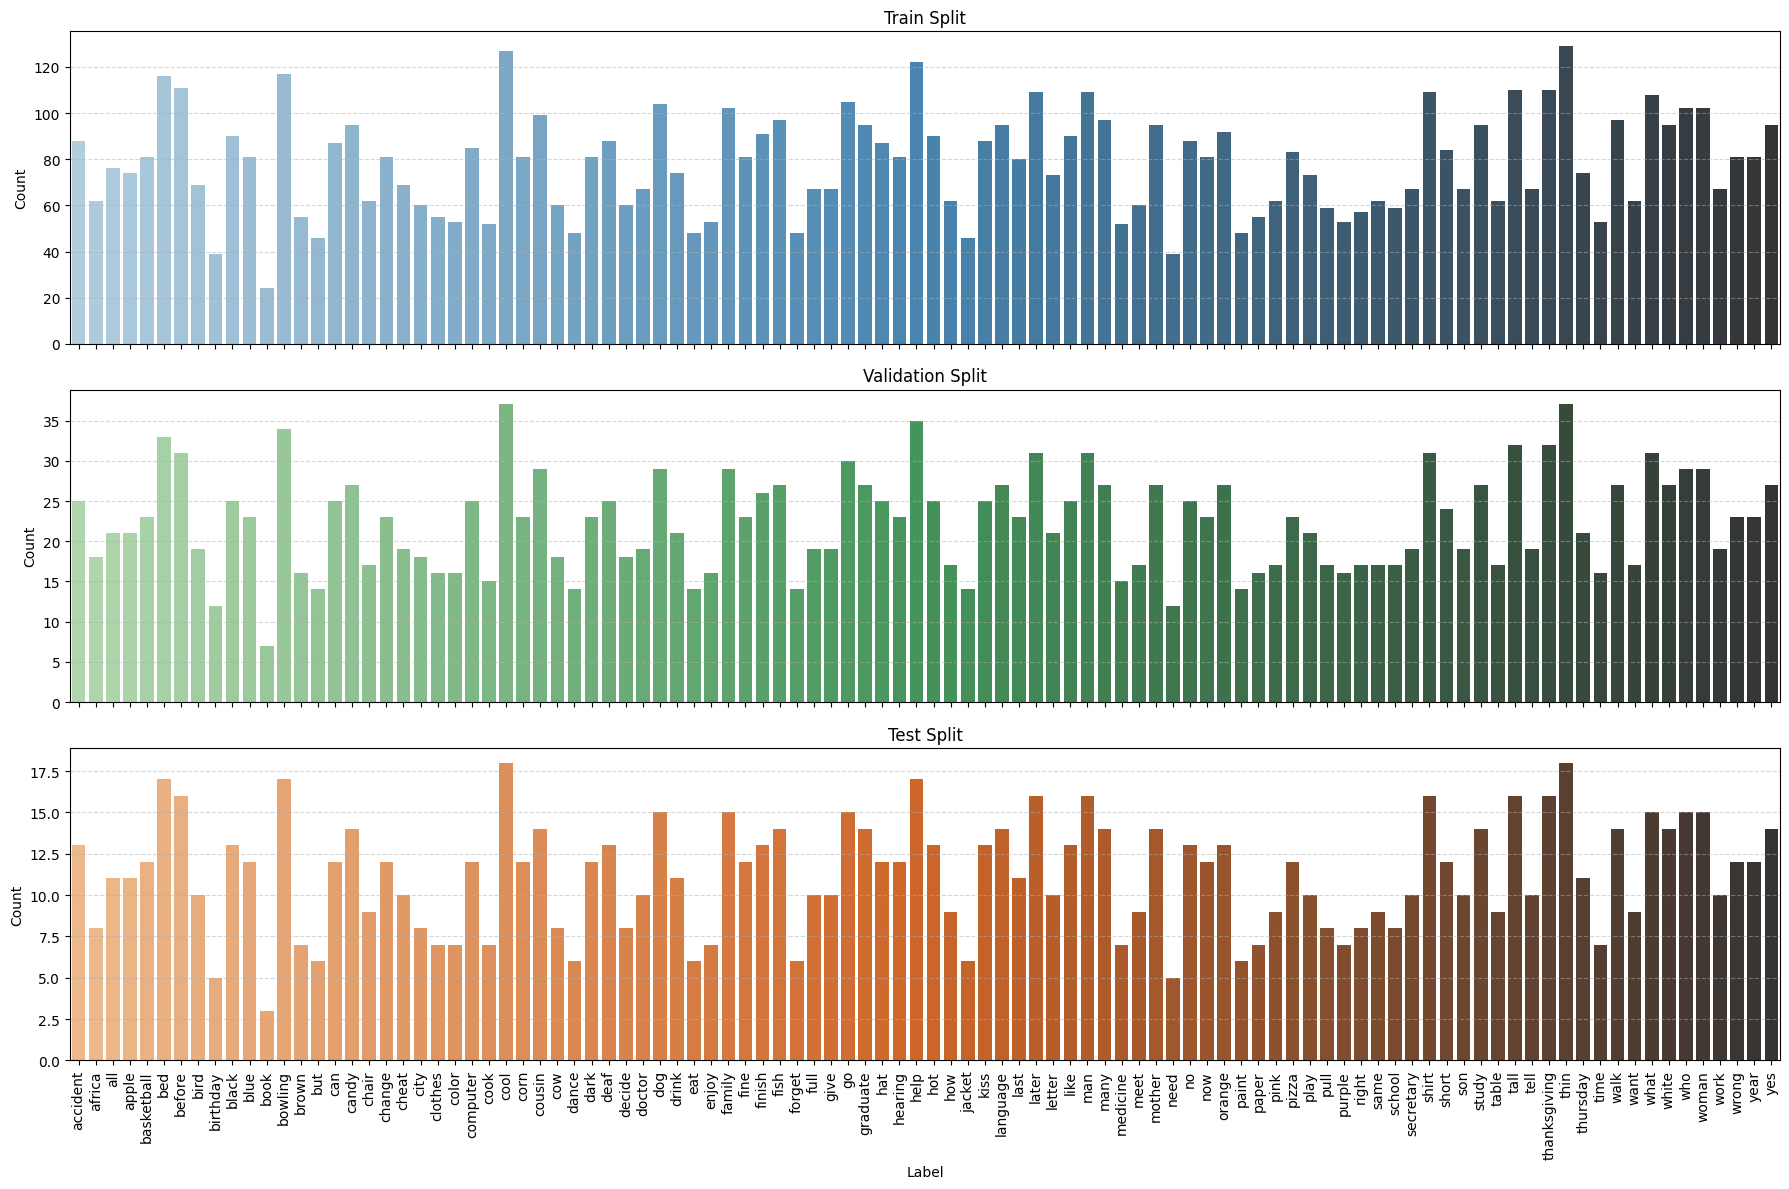

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "r") as f:
    label_to_idx = json.load(f)
idx_to_label = {v: k for k, v in label_to_idx.items()}

y_train = np.load(os.path.join(raw_frame_dir, "y_train.npy"))
y_val = np.load(os.path.join(raw_frame_dir, "y_val.npy"))
y_test = np.load(os.path.join(raw_frame_dir, "y_test.npy"))

def count_labels(y):
    counts = np.bincount(y, minlength=len(label_to_idx))
    return pd.DataFrame({
        "Label": [idx_to_label[i] for i in range(len(counts))],
        "Count": counts
    }).sort_values("Label")

df_train = count_labels(y_train)
df_val = count_labels(y_val)
df_test = count_labels(y_test)

def save_barplot(df, title, filename, color):
    plt.figure(figsize=(18, 24))
    sns.barplot(data=df, x="Label", y="Count", palette=color)
    plt.title(title)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.savefig(os.path.join(raw_frame_dir, filename))
    plt.close()

save_barplot(df_train, "Train Split: Videos per Label", "train_distribution.png", "Blues_d")
save_barplot(df_val, "Validation Split: Videos per Label", "val_distribution.png", "Greens_d")
save_barplot(df_test, "Test Split: Videos per Label", "test_distribution.png", "Oranges_d")

# --- Combined subplot figure ---
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

sns.barplot(data=df_train, x="Label", y="Count", ax=axes[0], palette="Blues_d")
axes[0].set_title("Train Split")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

sns.barplot(data=df_val, x="Label", y="Count", ax=axes[1], palette="Greens_d")
axes[1].set_title("Validation Split")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

sns.barplot(data=df_test, x="Label", y="Count", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Test Split")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Label")
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(raw_frame_dir, "combined_distribution.png"))
plt.show()

# === Cell 6: Imports ===

In [7]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

!pip install tf-keras -q         
!pip install tensorflow-model-optimization -q

import tensorflow as tf
import tf_keras              

from tf_keras.layers import (
    Input, TimeDistributed, Conv2D, MaxPooling2D,
    Flatten, Conv1D, GlobalAveragePooling1D, Dense
)
from tf_keras import Model
from tf_keras.utils import to_categorical

import numpy as np
import matplotlib.pyplot as plt
import json
import tensorflow_model_optimization as tfmot

print("TF version   :", tf.__version__)
print("tf_keras ver :", tf_keras.__version__)
print("TFMOT version:", tfmot.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxl

2026-04-04 09:41:42.825512: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775295703.009175      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775295703.067237      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775295703.527713      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775295703.527772      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775295703.527776      55 computation_placer.cc:177] computation placer alr

TF version   : 2.19.0
tf_keras ver : 2.19.0
TFMOT version: 0.8.0


# === Cell 7: Load Data ===

In [8]:
raw_frame_dir  = "/kaggle/working/frames_rgb"
label_map_path = os.path.join(raw_frame_dir, "label_to_idx.json")

X_train = np.load(os.path.join(raw_frame_dir, "X_train.npy"))
y_train = np.load(os.path.join(raw_frame_dir, "y_train.npy"))
X_val   = np.load(os.path.join(raw_frame_dir, "X_val.npy"))
y_val   = np.load(os.path.join(raw_frame_dir, "y_val.npy"))
X_test  = np.load(os.path.join(raw_frame_dir, "X_test.npy"))
y_test  = np.load(os.path.join(raw_frame_dir, "y_test.npy"))

with open(label_map_path, "r") as f:
    label_to_idx = json.load(f)

num_classes = len(label_to_idx)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val,   num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print(f"X_train : {X_train.shape}  |  classes: {num_classes}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")


X_train : (7835, 24, 64, 64, 1)  |  classes: 100
X_val   : (2239, 24, 64, 64, 1)
X_test  : (1120, 24, 64, 64, 1)


# === Cell 8: Dataset Pipelines ===

In [9]:
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train_cat))
            .shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val_cat))
            .cache().batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test_cat))
            .cache().batch(BATCH_SIZE).prefetch(AUTOTUNE))




I0000 00:00:1775295731.888004      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775295731.893895      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:

# Helper: Plot Training Curves 
def plot_history(history, title="Training"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"],         label="train loss")
    axes[0].plot(history.history["val_loss"],     label="val loss")
    axes[0].set_title(f"{title} — Loss");         axes[0].legend()
    axes[1].plot(history.history["accuracy"],     label="train acc")
    axes[1].plot(history.history["val_accuracy"], label="val acc")
    axes[1].set_title(f"{title} — Accuracy");     axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{title.replace(' ', '_')}.png")
    plt.show()

# === Cell 9: Build Flat S3D Model ===

In [11]:
import tf_keras
import tensorflow as tf
from tf_keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Conv1D, GlobalAveragePooling1D, Dense
)
from tf_keras import Model

def build_s3d_conv1d_flat(input_shape=(24, 64, 64, 1), num_classes=100):
    T, H, W, C = input_shape

    inputs = Input(shape=input_shape, name="video_input")  # (B, T, H, W, C)
    x = tf_keras.layers.Reshape((T * H, W, C), name="merge_time")(inputs)

    # ── Spatial CNN (inlined — no nested Model) ───────────────────────────────
    x = Conv2D(12, (3, 3), activation='relu', padding='same',
               name="conv2d_1")(x)                          # (B, T*H, W, 12)
    x = MaxPooling2D((2, 2), name="pool_1")(x)              # (B, T*H/2, W/2, 12)
    x = Conv2D(24, (3, 3), activation='relu', padding='same',
               name="conv2d_2")(x)                          # (B, T*H/2, W/2, 24)
    x = MaxPooling2D((2, 2), name="pool_2")(x)              # (B, T*H/4, W/4, 24)

    # ── Split time back out ───────────────────────────────────────────────────
    H_out = H // 4   # after 2× MaxPool(2,2)
    W_out = W // 4
    C_flat = H_out * W_out * 24  # e.g. 16*16*24 = 6144 for H=W=64

    # (B, T*H_out, W_out, 24) → (B, T, H_out * W_out * 24)
    x = tf_keras.layers.Reshape((T, C_flat), name="split_time")(x)

    # ── Temporal Conv1D ───────────────────────────────────────────────────────
    x = Conv1D(48, 3, padding='same', activation='relu',
               name="temporal_conv1d")(x)                   # (B, T, 48)
    x = GlobalAveragePooling1D(name="gap")(x)               # (B, 48)

    # ── Classifier ───────────────────────────────────────────────────────────
    outputs = Dense(num_classes, activation='softmax',
                    name="classifier")(x)

    return Model(inputs, outputs, name="S3D_Conv1D_Flat")


# ── Build and verify ──────────────────────────────────────────────────────────
input_shape = X_train.shape[1:]   # e.g. (24, 64, 64, 1)
float_model = build_s3d_conv1d_flat(input_shape, num_classes)
float_model.summary()

# Verify output shape
import numpy as np
dummy = np.zeros((1, *input_shape), dtype=np.float32)
out   = float_model(dummy)
print(f"\nOutput shape: {out.shape}  ← should be (1, {num_classes})")

# Parameter count comparison
total_params = float_model.count_params()
size_float32_kb = total_params * 4 / 1024
size_int8_kb    = total_params * 1 / 1024
print(f"\nTotal parameters : {total_params:,}")
print(f"Expected Float32 size : {size_float32_kb:.1f} KB")
print(f"Expected INT8 size    : {size_int8_kb:.1f} KB  "
      f"(theoretical {size_float32_kb/size_int8_kb:.0f}× reduction)")




Model: "S3D_Conv1D_Flat"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 video_input (InputLayer)    [(None, 24, 64, 64, 1)]   0         
                                                                 
 merge_time (Reshape)        (None, 1536, 64, 1)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 1536, 64, 12)      120       
                                                                 
 pool_1 (MaxPooling2D)       (None, 768, 32, 12)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 768, 32, 24)       2616      
                                                                 
 pool_2 (MaxPooling2D)       (None, 384, 16, 24)       0         
                                                                 
 split_time (Reshape)        (None, 24, 6144)      

I0000 00:00:1775295740.583908      55 cuda_dnn.cc:529] Loaded cuDNN version 91002



Output shape: (1, 100)  ← should be (1, 100)

Total parameters : 892,420
Expected Float32 size : 3486.0 KB
Expected INT8 size    : 871.5 KB  (theoretical 4× reduction)


# === Cell 10: Pre-Train Float32 ===


>>> PHASE 1: Float32 Pre-training <<<

Epoch 1/75


I0000 00:00:1775295745.648789   24596 service.cc:152] XLA service 0x7a51143e21d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775295745.648830   24596 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775295745.648834   24596 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775295745.924092   24596 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 [==============================] - ETA: 0s - loss: 4.5441 - accuracy: 0.0228
Epoch 1: val_accuracy improved from -inf to 0.03975, saving model to /kaggle/working/float_model_best.keras
245/245 [==============================] - 13s 39ms/step - loss: 4.5441 - accuracy: 0.0228 - val_loss: 4.4002 - val_accuracy: 0.0397 - lr: 0.0010
Epoch 2/75
245/245 [==============================] - ETA: 0s - loss: 4.0656 - accuracy: 0.0987
Epoch 2: val_accuracy improved from 0.03975 to 0.15141, saving model to /kaggle/working/float_model_best.keras
245/245 [==============================] - 8s 34ms/step - loss: 4.0656 - accuracy: 0.0987 - val_loss: 3.7868 - val_accuracy: 0.1514 - lr: 0.0010
Epoch 3/75
245/245 [==============================] - ETA: 0s - loss: 3.3381 - accuracy: 0.2216
Epoch 3: val_accuracy improved from 0.15141 to 0.24341, saving model to /kaggle/working/float_model_best.keras
245/245 [==============================] - 8s 34ms/step - loss: 3.3381 - accuracy: 0.2216 - val_loss: 

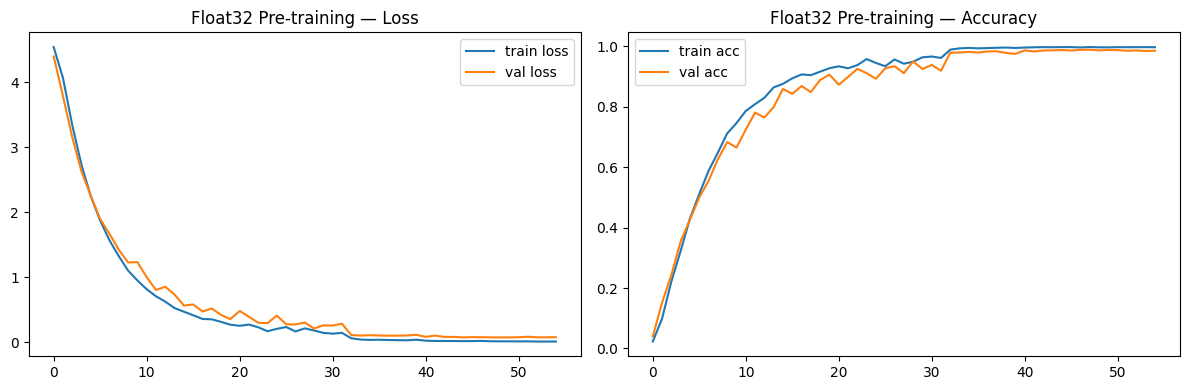


Float32 Test → loss: 0.0683  |  acc: 0.9875


In [12]:
float_model.compile(
    optimizer=tf_keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_pretrain = [
    tf_keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf_keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    tf_keras.callbacks.ModelCheckpoint(
        "/kaggle/working/float_model_best.keras",
        save_best_only=True, monitor="val_accuracy", verbose=1
    )
]

print("\n>>> PHASE 1: Float32 Pre-training <<<\n")
history_float = float_model.fit(
    train_ds, epochs=75,
    validation_data=val_ds,
    callbacks=callbacks_pretrain
)

plot_history(history_float, title="Float32 Pre-training")

float_loss, float_acc = float_model.evaluate(test_ds, verbose=0)
print(f"\nFloat32 Test → loss: {float_loss:.4f}  |  acc: {float_acc:.4f}")
float_model.save_weights("/kaggle/working/float_weights.weights.h5")

# ===  Cell 11: Full QAT ===

In [13]:
import tensorflow as tf
import tf_keras
import tensorflow_model_optimization as tfmot
import numpy as np

quantize_annotate_layer = tfmot.quantization.keras.quantize_annotate_layer
quantize_apply          = tfmot.quantization.keras.quantize_apply
quantize_scope          = tfmot.quantization.keras.quantize_scope
LastValueQuantizer      = tfmot.quantization.keras.quantizers.LastValueQuantizer
MovingAverageQuantizer  = tfmot.quantization.keras.quantizers.MovingAverageQuantizer

from tf_keras.layers import (
    Input, Conv2D, MaxPooling2D,
    Conv1D, GlobalAveragePooling1D, Dense
)
from tf_keras import Model

# ── Ablation parameter 
CONV1D_KERNEL = 3   # Ablation study with k= 1, 5, or 7

# ── Custom QuantizeConfig for Conv1D ─────────────────────────────────────────
class Conv1DQuantizeConfig(tfmot.quantization.keras.QuantizeConfig):
    def get_weights_and_quantizers(self, layer):
        return [(layer.kernel,
                 LastValueQuantizer(num_bits=8, symmetric=True,
                                    narrow_range=False, per_axis=False))]
    def get_activations_and_quantizers(self, layer):
        return [(layer.activation,
                 MovingAverageQuantizer(num_bits=8, symmetric=False,
                                        narrow_range=False, per_axis=False))]
    def set_quantize_weights(self, layer, quantize_weights):
        layer.kernel = quantize_weights[0]
    def set_quantize_activations(self, layer, quantize_activations):
        layer.activation = quantize_activations[0]
    def get_output_quantizers(self, layer):
        return [LastValueQuantizer(num_bits=8, symmetric=False,
                                   narrow_range=False, per_axis=False)]
    def get_config(self):
        return {}

# ── Build annotated model ─────────────────────────────────────────────────────
def build_s3d_conv1d_flat_annotated(input_shape, num_classes):
    T, H, W, C = input_shape       # T=8 here; H=W=64, C=1
    H_out  = H // 4               # 16  (after 2× MaxPool(2,2))
    W_out  = W // 4               # 16
    C_flat = H_out * W_out * 24   # 16*16*24 = 6144

    inputs = Input(shape=input_shape, name="video_input")

    # (B, 8, 64, 64, 1) → (B, 8*64, 64, 1) = (B, 512, 64, 1)
    x = tf_keras.layers.Reshape((T * H, W, C), name="merge_time")(inputs)

    x = quantize_annotate_layer(
            Conv2D(12, (3,3), activation='relu', padding='same', name="conv2d_1")
        )(x)
    x = MaxPooling2D((2,2), name="pool_1")(x)
    x = quantize_annotate_layer(
            Conv2D(24, (3,3), activation='relu', padding='same', name="conv2d_2")
        )(x)
    x = MaxPooling2D((2,2), name="pool_2")(x)

    # (B, 8*H_out, W_out, 24) → (B, 8, 6144)
    x = tf_keras.layers.Reshape((T, C_flat), name="split_time")(x)

    x = quantize_annotate_layer(
            Conv1D(48, CONV1D_KERNEL, padding='same', activation='relu',
                   name="temporal_conv1d"),
            quantize_config=Conv1DQuantizeConfig()
        )(x)
    x = GlobalAveragePooling1D(name="gap")(x)
    outputs = quantize_annotate_layer(
                  Dense(num_classes, activation='softmax', name="classifier")
              )(x)
    return Model(inputs, outputs, name=f"S3D_Conv1D_Flat_Annotated_T{T}_K{CONV1D_KERNEL}")

annotated_model = build_s3d_conv1d_flat_annotated(input_shape, num_classes)

with quantize_scope({"Conv1DQuantizeConfig": Conv1DQuantizeConfig}):
    qat_model = quantize_apply(annotated_model)

# ── Step 1: Transfer weights ──────────────────────────────────────────────────
float_lookup = {l.name: l for l in float_model.layers if l.get_weights()}

print(f"Ablation: T={input_shape[0]}  Conv1D kernel={CONV1D_KERNEL}")
print("Weight transfer log:")
print("─" * 70)
transferred = 0
skipped     = 0

for ql in qat_model.layers:
    inner         = getattr(ql, "layer", None)
    original_name = inner.name if inner is not None else ql.name

    if original_name not in float_lookup:
        continue

    fl = float_lookup[original_name]
    fw = fl.get_weights()
    qw = ql.get_weights()

    if len(qw) >= len(fw) and all(a.shape == b.shape
                                   for a, b in zip(fw, qw[:len(fw)])):
        ql.set_weights(fw + qw[len(fw):])
        transferred += 1
        print(f"  ✓  {ql.name:45s}  "
              f"({len(fw)} weights + {len(qw)-len(fw)} trackers)")
    else:
        success = 0
        fw_map = {}
        if len(fw) > 0: fw_map["kernel"] = fw[0]
        if len(fw) > 1: fw_map["bias"]   = fw[1]
        for var in ql.weights:
            for kw, arr in fw_map.items():
                if kw in var.name and var.shape == arr.shape:
                    var.assign(arr)
                    success += 1
        if success > 0:
            transferred += 1
            print(f"  ✓  {ql.name:45s}  (direct assign, {success} vars)")
        else:
            skipped += 1
            print(f"  ✗  {ql.name:45s}  no match found")

print("─" * 70)
print(f"Transferred: {transferred}  |  Skipped: {skipped}")

# ── Step 2: Initialise Conv1D tracker variables ───────────────────────────────
print("\nInitialising Conv1D tracker variables from float kernel range...")

fl_conv1d = float_model.get_layer("temporal_conv1d")
fl_kernel  = fl_conv1d.get_weights()[0]
k_min = float(fl_kernel.min())
k_max = float(fl_kernel.max())

sample_batch = next(iter(train_ds))[0][:4]
_ = float_model(sample_batch, training=False)

qat_conv1d_wrapper = next(
    l for l in qat_model.layers if "temporal_conv1d" in l.name
)

seeded = 0
for var in qat_conv1d_wrapper.weights:
    vname = var.name
    if "kernel_min" in vname:
        var.assign(tf.constant(k_min));  seeded += 1
        print(f"  ✓  {vname:55s} ← {k_min:.4f}")
    elif "kernel_max" in vname:
        var.assign(tf.constant(k_max));  seeded += 1
        print(f"  ✓  {vname:55s} ← {k_max:.4f}")
    elif "post_activation_min" in vname or "output_min" in vname:
        var.assign(tf.constant(-6.0));   seeded += 1
        print(f"  ✓  {vname:55s} ← -6.0")
    elif "post_activation_max" in vname or "output_max" in vname:
        var.assign(tf.constant(6.0));    seeded += 1
        print(f"  ✓  {vname:55s} ←  6.0")

print(f"\nSeeded {seeded} tracker variables")

# ── Step 3: Verify ────────────────────────────────────────────────────────────
print("\nVerification — kernel ranges after seeding (one forward pass):")

qat_model.compile(
    optimizer=tf_keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
_ = qat_model(sample_batch, training=False)

for ql in qat_model.layers:
    inner         = getattr(ql, "layer", None)
    original_name = inner.name if inner is not None else ql.name
    if original_name not in float_lookup:
        continue
    for var in ql.weights:
        if "kernel" in var.name and len(var.shape) > 1:
            r    = float(var.numpy().max() - var.numpy().min())
            flag = "✓" if r > 0.5 else "⚠  near-zero — still broken"
            print(f"  {flag}  {ql.name:45s}  range={r:.4f}")
            break

# ── Step 4: Sanity check ──────────────────────────────────────────────────────
_, pre_acc = qat_model.evaluate(val_ds, verbose=0)
print(f"\nSanity check — val acc before fine-tuning: {pre_acc:.4f}  "
      f"(float32 = {float_acc:.4f})")
if pre_acc >= float_acc - 0.10:
    print("  ✓  Transfer successful — proceed to Cell 8")
else:
    print("  ⚠  Still failing — paste output above")

qat_model.summary()

Ablation: T=24  Conv1D kernel=3
Weight transfer log:
──────────────────────────────────────────────────────────────────────
  ✓  quant_conv2d_1                                 (2 weights + 5 trackers)
  ✓  quant_conv2d_2                                 (2 weights + 5 trackers)
  ✓  quant_temporal_conv1d                          (2 weights + 7 trackers)
  ✓  quant_classifier                               (2 weights + 5 trackers)
──────────────────────────────────────────────────────────────────────
Transferred: 4  |  Skipped: 0

Initialising Conv1D tracker variables from float kernel range...
  ✓  quant_temporal_conv1d/kernel_min:0                      ← -0.9752
  ✓  quant_temporal_conv1d/kernel_max:0                      ← 1.0185
  ✓  quant_temporal_conv1d/post_activation_min:0             ← -6.0
  ✓  quant_temporal_conv1d/post_activation_max:0             ←  6.0
  ✓  quant_temporal_conv1d/output_min:0                      ← -6.0
  ✓  quant_temporal_conv1d/output_max:0                 

# === Cell 12: Pre-Finetune Diagnostic ===

In [15]:
# Run this BEFORE fine-tuning to understand where the
# accuracy gap is coming from.

print("=" * 60)
print("  PRE-FINETUNE DIAGNOSTIC")
print("=" * 60)

# 1. Check pre-finetune accuracy on all splits
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    _, acc = qat_model.evaluate(ds, verbose=0)
    print(f"  QAT {name:5s} acc (before finetune): {acc:.4f}")

print(f"\n  Float32 reference acc             : {float_acc:.4f}")

# 2. Inspect weight ranges — wide ranges = large quantization error
print("\n  Kernel weight ranges (QAT model):")
for layer in qat_model.layers:
    weights = layer.get_weights()
    if not weights:
        continue
    kernel = weights[0]
    w_range = kernel.max() - kernel.min()
    print(f"    {layer.name:45s}  range={w_range:.4f}  "
          f"min={kernel.min():.4f}  max={kernel.max():.4f}")

# 3. Check if any QAT min/max trackers are at extreme defaults
print("\n  QAT quantization tracker values (should not be ±inf or 0):")
for layer in qat_model.layers:
    weights = layer.get_weights()
    if len(weights) <= 2:
        continue   # no tracker variables
    for i, w in enumerate(weights[2:], start=2):
        if w.ndim == 0 or w.size <= 2:
            print(f"    {layer.name:45s}  tracker[{i}] = {w.flatten()}")

  PRE-FINETUNE DIAGNOSTIC
  QAT train acc (before finetune): 0.2384
  QAT val   acc (before finetune): 0.2273
  QAT test  acc (before finetune): 0.2259

  Float32 reference acc             : 0.9875

  Kernel weight ranges (QAT model):
    quant_merge_time                               range=0.0000  min=-1.0000  max=-1.0000
    quant_conv2d_1                                 range=1.6453  min=-0.5838  max=1.0614
    quant_pool_1                                   range=0.0000  min=-1.0000  max=-1.0000
    quant_conv2d_2                                 range=2.1958  min=-1.1665  max=1.0293
    quant_split_time                               range=0.0000  min=-1.0000  max=-1.0000
    quant_temporal_conv1d                          range=1.9937  min=-0.9752  max=1.0185
    quant_gap                                      range=0.0000  min=-1.0000  max=-1.0000
    quant_classifier                               range=2.4721  min=-1.9831  max=0.4890

  QAT quantization tracker values (should not be

# === Cell 13: Improved QAT Fine-Tuning ===


>>> PHASE 2a: QAT Warm-up (stabilise quantization ranges) <<<

Epoch 1/15
245/245 [==============================] - 19s 68ms/step - loss: 3.6419 - accuracy: 0.1927 - val_loss: 3.6782 - val_accuracy: 0.2613
Epoch 2/15
245/245 [==============================] - 16s 67ms/step - loss: 3.0131 - accuracy: 0.4168 - val_loss: 2.4259 - val_accuracy: 0.5145
Epoch 3/15
245/245 [==============================] - 16s 67ms/step - loss: 1.5075 - accuracy: 0.6550 - val_loss: 1.0419 - val_accuracy: 0.7258
Epoch 4/15
245/245 [==============================] - 16s 67ms/step - loss: 0.6000 - accuracy: 0.8121 - val_loss: 0.4331 - val_accuracy: 0.8647
Epoch 5/15
245/245 [==============================] - 16s 67ms/step - loss: 0.2642 - accuracy: 0.9110 - val_loss: 0.2240 - val_accuracy: 0.9285
Epoch 6/15
245/245 [==============================] - 16s 67ms/step - loss: 0.1376 - accuracy: 0.9496 - val_loss: 0.1478 - val_accuracy: 0.9513
Epoch 7/15
245/245 [==============================] - 16s 67ms/step - lo

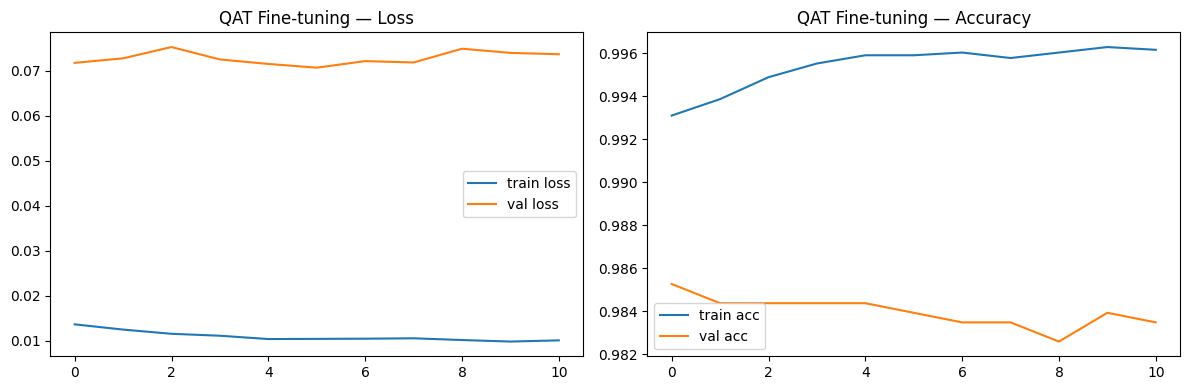


QAT Test  →  loss: 0.0714  |  acc: 0.9839


In [16]:
#   1. Warm-up phase at very low LR to stabilise fake-quant ranges
#   2. Main phase with moderate LR
#   3. Both phases use gradient clipping to prevent instability

import tensorflow as tf
import tf_keras

# ── Phase 1: Warm-up (freeze BN-style, stabilise quant ranges) ───────────────
print("\n>>> PHASE 2a: QAT Warm-up (stabilise quantization ranges) <<<\n")

qat_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=1e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_warmup = qat_model.fit(
    train_ds,
    epochs=15,                        # just enough to calibrate fake-quant ranges
    validation_data=val_ds,
    verbose=1
)

warmup_loss, warmup_acc = qat_model.evaluate(val_ds, verbose=0)
print(f"\nAfter warm-up  →  val acc: {warmup_acc:.4f}")

# ── Phase 2: Main fine-tuning ─────────────────────────────────────────────────
print("\n>>> PHASE 2b: QAT Main Fine-Tuning <<<\n")

qat_model.compile(
    optimizer=tf_keras.optimizers.Adam(
        learning_rate=1e-5,
        clipnorm=1.0              # gradient clipping prevents large weight shifts
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_qat = [
    tf_keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True,
        monitor="val_accuracy"
    ),
    tf_keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=3,
        min_lr=1e-7,
        monitor="val_accuracy",
        verbose=1
    ),
    tf_keras.callbacks.ModelCheckpoint(
        "/kaggle/working/qat_model_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        verbose=1
    )
]

history_qat = qat_model.fit(
    train_ds,
    epochs=100,                    # more epochs with early stopping as safety net
    validation_data=val_ds,
    callbacks=callbacks_qat
)

plot_history(history_qat, title="QAT Fine-tuning")

qat_loss, qat_acc = qat_model.evaluate(test_ds, verbose=0)
print(f"\nQAT Test  →  loss: {qat_loss:.4f}  |  acc: {qat_acc:.4f}")

# === Cell 14: Convert to TFLite INT8 ===

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for x_batch, _ in train_ds.take(100):
        for sample in x_batch:
            yield [tf.expand_dims(tf.cast(sample, tf.float32), axis=0)]

converter.representative_dataset    = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8

tflite_model = converter.convert()

tflite_path = "/kaggle/working/s3d_conv1d_qat_int8.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"TFLite model saved → {tflite_path}")

INFO:tensorflow:Assets written to: /tmp/tmptk21p1bp/assets


INFO:tensorflow:Assets written to: /tmp/tmptk21p1bp/assets
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1775296684.979022      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775296684.979078      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1775296685.003018      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite model saved → /kaggle/working/s3d_conv1d_qat_int8.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


# === Cell 15: Final Comparison Summary ===

In [18]:
import os

float_size  = os.path.getsize("/kaggle/working/float_model_best.keras") / 1024
tflite_size = os.path.getsize(tflite_path) / 1024

print("\n" + "=" * 52)
print("          MODEL COMPARISON SUMMARY")
print("=" * 52)
print(f"  Float32  →  acc: {float_acc:.4f}  |  size: {float_size:.1f} KB")
print(f"  QAT INT8 →  acc: {qat_acc:.4f}  |  size: {tflite_size:.1f} KB")
print(f"  Size reduction : {(1 - tflite_size / float_size) * 100:.1f}%")
print(f"  Accuracy drop  : {(float_acc - qat_acc) * 100:.2f}%")
print("=" * 52)

# Guidance based on result
drop = (float_acc - qat_acc) * 100
if drop < 2:
    print("\n  ✓  Excellent — QAT fully recovered float32 accuracy.")
elif drop < 5:
    print("\n  ✓  Good — acceptable drop for INT8 deployment.")
elif drop < 10:
    print("\n  ⚠  Moderate drop. Consider training float32 longer before QAT.")
else:
    print("\n  ✗  Large drop. See notes below.")


          MODEL COMPARISON SUMMARY
  Float32  →  acc: 0.9875  |  size: 10501.3 KB
  QAT INT8 →  acc: 0.9839  |  size: 880.3 KB
  Size reduction : 91.6%
  Accuracy drop  : 0.36%

  ✓  Excellent — QAT fully recovered float32 accuracy.


# === Cell 16: Fair Model Size Comparison ===

INFO:tensorflow:Assets written to: /kaggle/working/float_model_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/float_model_savedmodel/assets


INFO:tensorflow:Assets written to: /tmp/tmp_ffxdhas/assets


INFO:tensorflow:Assets written to: /tmp/tmp_ffxdhas/assets
W0000 00:00:1775296771.971136      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775296771.971164      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.



   TRUE MODEL SIZE COMPARISON
  Format                                Size (KB)
----------------------------------------------------------
  .keras (with optimizer)                 10501.3 KB
  SavedModel (no optimizer)                3629.2 KB
  Weights-only .h5                        10495.6 KB
  TFLite float32                           3492.1 KB
  TFLite INT8 (QAT)                         880.3 KB

  DEPLOYMENT-RELEVANT COMPARISON
  ─────────────────────────────────────────────────────
  Float32 TFLite  :    3492.1 KB   (what runs on device without quant)
  INT8 QAT TFLite :     880.3 KB   (what actually deploys)
  ─────────────────────────────────────────────────────
  Size reduction  :  74.8%
  Compression ratio: 4.0×
  ─────────────────────────────────────────────────────
  The .keras file (10501 KB) is 3.0× larger than
  the float32 TFLite because it includes Adam optimizer
  state (momentum + variance tensors for every weight).
  Never use .keras file size for deployment compa

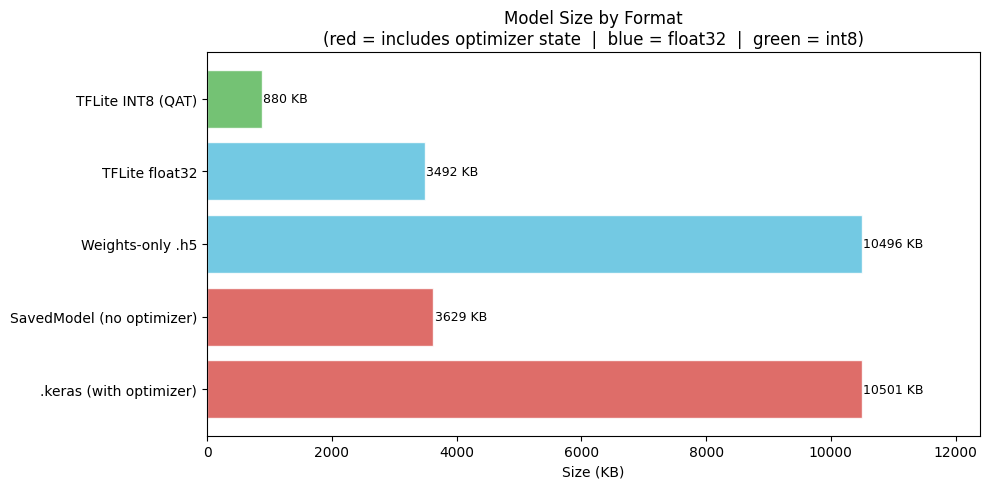

In [19]:
# .tflite saves weights + graph only 
# save float model as weights-only formats for fair comparison

import os
import numpy as np
import tensorflow as tf

# ── 1. Save float model in weights-only formats ───────────────────────────────

# Option A: SavedModel format (no optimizer state if include_optimizer=False)
float_model.save(
    "/kaggle/working/float_model_savedmodel",
    include_optimizer=False          # strips Adam state
)

# Option B: Raw weights only as .h5
float_model.save_weights("/kaggle/working/float_weights_only.weights.h5")

# Option C: Convert float model itself to TFLite (float32, no quantization)
#           — most direct comparison with the INT8 tflite
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(float_model)
# No optimizations = pure float32 flatbuffer
tflite_float32 = converter_f32.convert()
tflite_float32_path = "/kaggle/working/s3d_conv1d_float32.tflite"
with open(tflite_float32_path, "wb") as f:
    f.write(tflite_float32)

# ── 2. Collect sizes ──────────────────────────────────────────────────────────

def folder_size_kb(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for fname in filenames:
            total += os.path.getsize(os.path.join(dirpath, fname))
    return total / 1024

sizes = {
    ".keras (with optimizer)"   : os.path.getsize("/kaggle/working/float_model_best.keras") / 1024,
    "SavedModel (no optimizer)" : folder_size_kb("/kaggle/working/float_model_savedmodel"),
    "Weights-only .h5"          : os.path.getsize("/kaggle/working/float_weights_only.weights.h5") / 1024,
    "TFLite float32"            : os.path.getsize(tflite_float32_path) / 1024,
    "TFLite INT8 (QAT)"         : os.path.getsize("/kaggle/working/s3d_conv1d_qat_int8.tflite") / 1024,
}

# Add PTQ tflite if it exists
ptq_path = "/kaggle/working/frames_rgb/s3d_conv1d_int8_300.tflite"
if os.path.exists(ptq_path):
    sizes["TFLite INT8 (PTQ)"] = os.path.getsize(ptq_path) / 1024

# ── 3. Print comparison ───────────────────────────────────────────────────────

print("\n" + "=" * 58)
print("   TRUE MODEL SIZE COMPARISON")
print("=" * 58)
print(f"  {'Format':<35s}  {'Size (KB)':>10s}")
print("-" * 58)
for label, size_kb in sizes.items():
    print(f"  {label:<35s}  {size_kb:>10.1f} KB")
print("=" * 58)

# ── 4. The number that actually matters for deployment ────────────────────────
f32_tflite_kb  = sizes["TFLite float32"]
int8_qat_kb    = sizes["TFLite INT8 (QAT)"]
reduction      = (1 - int8_qat_kb / f32_tflite_kb) * 100
ratio          = f32_tflite_kb / int8_qat_kb

print(f"""
  DEPLOYMENT-RELEVANT COMPARISON
  ─────────────────────────────────────────────────────
  Float32 TFLite  :  {f32_tflite_kb:>8.1f} KB   (what runs on device without quant)
  INT8 QAT TFLite :  {int8_qat_kb:>8.1f} KB   (what actually deploys)
  ─────────────────────────────────────────────────────
  Size reduction  :  {reduction:.1f}%
  Compression ratio: {ratio:.1f}×
  ─────────────────────────────────────────────────────
  The .keras file ({sizes['.keras (with optimizer)']:.0f} KB) is {sizes['.keras (with optimizer)']/f32_tflite_kb:.1f}× larger than
  the float32 TFLite because it includes Adam optimizer
  state (momentum + variance tensors for every weight).
  Never use .keras file size for deployment comparisons.
""")

# ── 5. Visual bar chart ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt

labels = list(sizes.keys())
values = list(sizes.values())
colors = ["#d9534f" if "optimizer" in l else
          "#5bc0de" if "float32" in l.lower() or "SavedModel" in l or "h5" in l
          else "#5cb85c" for l in labels]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, values, color=colors, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{val:.0f} KB", va="center", fontsize=9)

ax.set_xlabel("Size (KB)")
ax.set_title("Model Size by Format\n"
             "(red = includes optimizer state  |  blue = float32  |  green = int8)")
ax.set_xlim(0, max(values) * 1.18)
plt.tight_layout()
plt.savefig("/kaggle/working/model_size_comparison.png")
plt.show()

# === Cell 17: Weight Range & Quant Params ===

In [20]:
# For each quantizable layer we compute:
#   x_min, x_max  → actual weight range
#   scale         → (x_max - x_min) / 255
#   zero_point    → where 0.0 maps to on the int8 grid
# This is exactly what TFLite uses internally during INT8 inference.

import pandas as pd

def compute_quant_params(w_flat):
    """Given a flattened weight array, return quant params."""
    x_min  = float(w_flat.min())
    x_max  = float(w_flat.max())
    scale  = (x_max - x_min) / 255.0
    # zero_point: int8 value that maps back to 0.0 float
    zp     = round(-x_min / scale) if scale > 0 else 0
    zp     = int(np.clip(zp, -128, 127))   # clamp to int8 range
    return x_min, x_max, scale, zp

rows = []

for layer in float_model.layers:
    weights = layer.get_weights()
    if not weights:
        continue   # skip layers with no weights (MaxPool, Flatten, etc.)

    for i, w in enumerate(weights):
        w_flat        = w.flatten()
        param_type    = "kernel" if i == 0 else "bias"
        x_min, x_max, scale, zp = compute_quant_params(w_flat)

        rows.append({
            "layer"      : layer.name,
            "param"      : param_type,
            "shape"      : str(w.shape),
            "x_min"      : round(x_min,  6),
            "x_max"      : round(x_max,  6),
            "range"      : round(x_max - x_min, 6),
            "scale"      : round(scale,  8),
            "zero_point" : zp,
        })

df = pd.DataFrame(rows)

# ── pretty print ──────────────────────────────────────
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 120)

print("\n" + "="*100)
print("   WEIGHT QUANTIZATION PARAMETERS  (Float32 model — kernels & biases)")
print("="*100)
display(df)

# ── per-layer kernel summary (just kernels, easier to read) ──
print("\n" + "="*80)
print("   KERNEL-ONLY SUMMARY")
print("="*80)
kernels = df[df["param"] == "kernel"][["layer","shape","x_min","x_max","scale","zero_point"]]
display(kernels.reset_index(drop=True))





   WEIGHT QUANTIZATION PARAMETERS  (Float32 model — kernels & biases)


,layer,param,shape,x_min,x_max,range,scale,zero_point
0,conv2d_1,kernel,"(3, 3, 1, 12)",-0.583847,1.061428,1.645275,0.006452,90
1,conv2d_1,bias,"(12,)",-0.479489,0.043744,0.523233,0.002052,127
2,conv2d_2,kernel,"(3, 3, 12, 24)",-1.166507,1.029330,2.195838,0.008611,127
3,conv2d_2,bias,"(24,)",-0.218701,0.079732,0.298433,0.001170,127
4,temporal_conv1d,kernel,"(3, 6144, 48)",-0.975197,1.018540,1.993737,0.007819,125
5,temporal_conv1d,bias,"(48,)",-0.046562,0.131022,0.177584,0.000696,67
6,classifier,kernel,"(48, 100)",-1.983081,0.488979,2.472061,0.009694,127
7,classifier,bias,"(100,)",-0.517677,0.433822,0.951499,0.003731,127



   KERNEL-ONLY SUMMARY


,layer,shape,x_min,x_max,scale,zero_point
0,conv2d_1,"(3, 3, 1, 12)",-0.583847,1.061428,0.006452,90
1,conv2d_2,"(3, 3, 12, 24)",-1.166507,1.029330,0.008611,127
2,temporal_conv1d,"(3, 6144, 48)",-0.975197,1.018540,0.007819,125
3,classifier,"(48, 100)",-1.983081,0.488979,0.009694,127


# === Cell 18: Before vs After QAT Comparison ===


   FLOAT32 vs QAT — KERNEL WEIGHT RANGE COMPARISON
   (tighter range after QAT = less quantization error)


range             scale             x_max               x_min           zero_point           
model                  Float32      QAT  Float32      QAT  Float32       QAT   Float32       QAT    Float32        QAT
layer                                                                                                                 
classifier            2.472061      NaN 0.009694      NaN 0.488979       NaN -1.983081       NaN 127.000000        NaN
conv2d_1              1.645275      NaN 0.006452      NaN 1.061428       NaN -0.583847       NaN  90.000000        NaN
conv2d_2              2.195838      NaN 0.008611      NaN 1.029330       NaN -1.166507       NaN 127.000000        NaN
quant_classifier           NaN 2.473025      NaN 0.009698      NaN  0.489574       NaN -1.983452        NaN 127.000000
quant_conv2d_1             NaN 1.644354      NaN 0.006448      NaN  1.060789       NaN -0.583566        NaN  90.000000
quant_conv2d_2             NaN 2.195495      NaN 0.008610      NaN  1.028776       NaN -1.166719        NaN 127.000000
quant_gap                  NaN 0.000000      NaN 0.000000      NaN -1.000000       NaN -1.000000        NaN   0.000000
quant_merge_time           NaN 0.000000      NaN 0.000000      NaN -1.000000       NaN -1.000000        NaN   0.000000
quant_pool_1               NaN 0.000000      NaN 0.000000      NaN -1.000000       NaN -1.000000        NaN   0.000000
quant_split_time           NaN 0.000000      NaN 0.000000      NaN -1.000000       NaN -1.000000        NaN   0.000000
quant_temporal_conv1d      NaN 1.993815      NaN 0.007819      NaN  1.018540       NaN -0.975274        NaN 125.000000
temporal_conv1d       1.993737      NaN 0.007819      NaN 1.018540       NaN -0.975197       NaN 125.000000        NaN

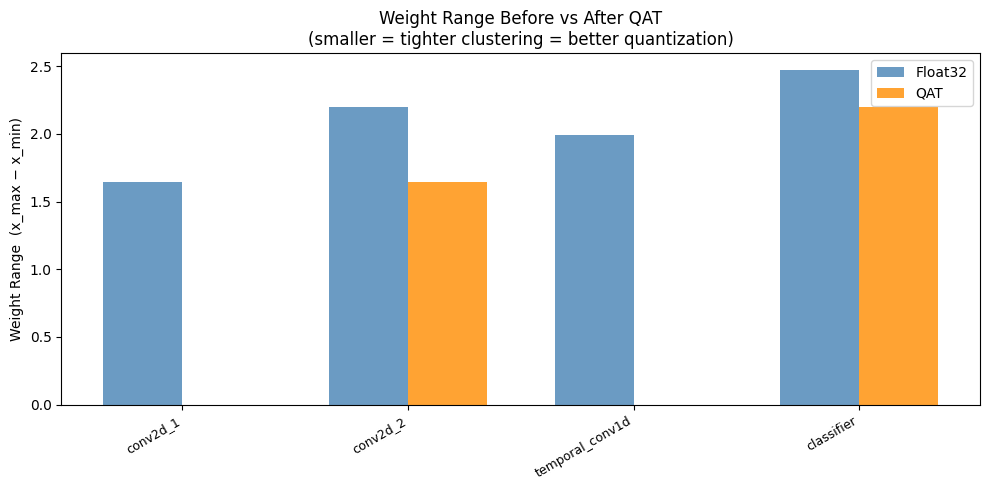

In [22]:
# Compare float32 vs QAT weight ranges side by side.

def get_quant_rows(model, label):
    rows = []
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        w_flat = weights[0].flatten()   # kernel only
        x_min, x_max, scale, zp = compute_quant_params(w_flat)
        rows.append({
            "model"      : label,
            "layer"      : layer.name,
            "x_min"      : round(x_min,  6),
            "x_max"      : round(x_max,  6),
            "range"      : round(x_max - x_min, 6),
            "scale"      : round(scale,  8),
            "zero_point" : zp,
        })
    return rows

rows_float = get_quant_rows(float_model, "Float32")
rows_qat   = get_quant_rows(qat_model,   "QAT")

df_compare = pd.DataFrame(rows_float + rows_qat)
df_pivot   = df_compare.pivot_table(
    index="layer",
    columns="model",
    values=["x_min","x_max","range","scale","zero_point"]
)

print("\n" + "="*100)
print("   FLOAT32 vs QAT — KERNEL WEIGHT RANGE COMPARISON")
print("   (tighter range after QAT = less quantization error)")
print("="*100)
display(df_pivot)

# ── bar chart: weight range (x_max - x_min) before vs after ──
layers_float = [r["layer"] for r in rows_float]
ranges_float = [r["range"] for r in rows_float]
ranges_qat   = [r["range"] for r in rows_qat[:len(rows_float)]]

x = np.arange(len(layers_float))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, ranges_float, width, label="Float32", color="steelblue", alpha=0.8)
ax.bar(x + width/2, ranges_qat,   width, label="QAT",     color="darkorange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(layers_float, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Weight Range  (x_max − x_min)")
ax.set_title("Weight Range Before vs After QAT\n(smaller = tighter clustering = better quantization)")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/weight_range_comparison.png")
plt.show()

# === Cell 19: Top 20 Most Frequent Error Heatmap ===

Running inference on test set...

Total errors   : 18
Total samples  : 1120
Error rate     : 1.61%

Top 20 most frequent (true → predicted) errors:
───────────────────────────────────────────────────────
   1. [  2×]  'tell'  →  'hearing'
   2. [  2×]  'paint'  →  'dark'
   3. [  2×]  'hat'  →  'black'
   4. [  2×]  'secretary'  →  'city'
   5. [  2×]  'city'  →  'cool'
   6. [  1×]  'wrong'  →  'accident'
   7. [  1×]  'cow'  →  'black'
   8. [  1×]  'wrong'  →  'africa'
   9. [  1×]  'before'  →  'thin'
  10. [  1×]  'candy'  →  'corn'
  11. [  1×]  'tall'  →  'black'
  12. [  1×]  'before'  →  'last'
  13. [  1×]  'thin'  →  'short'


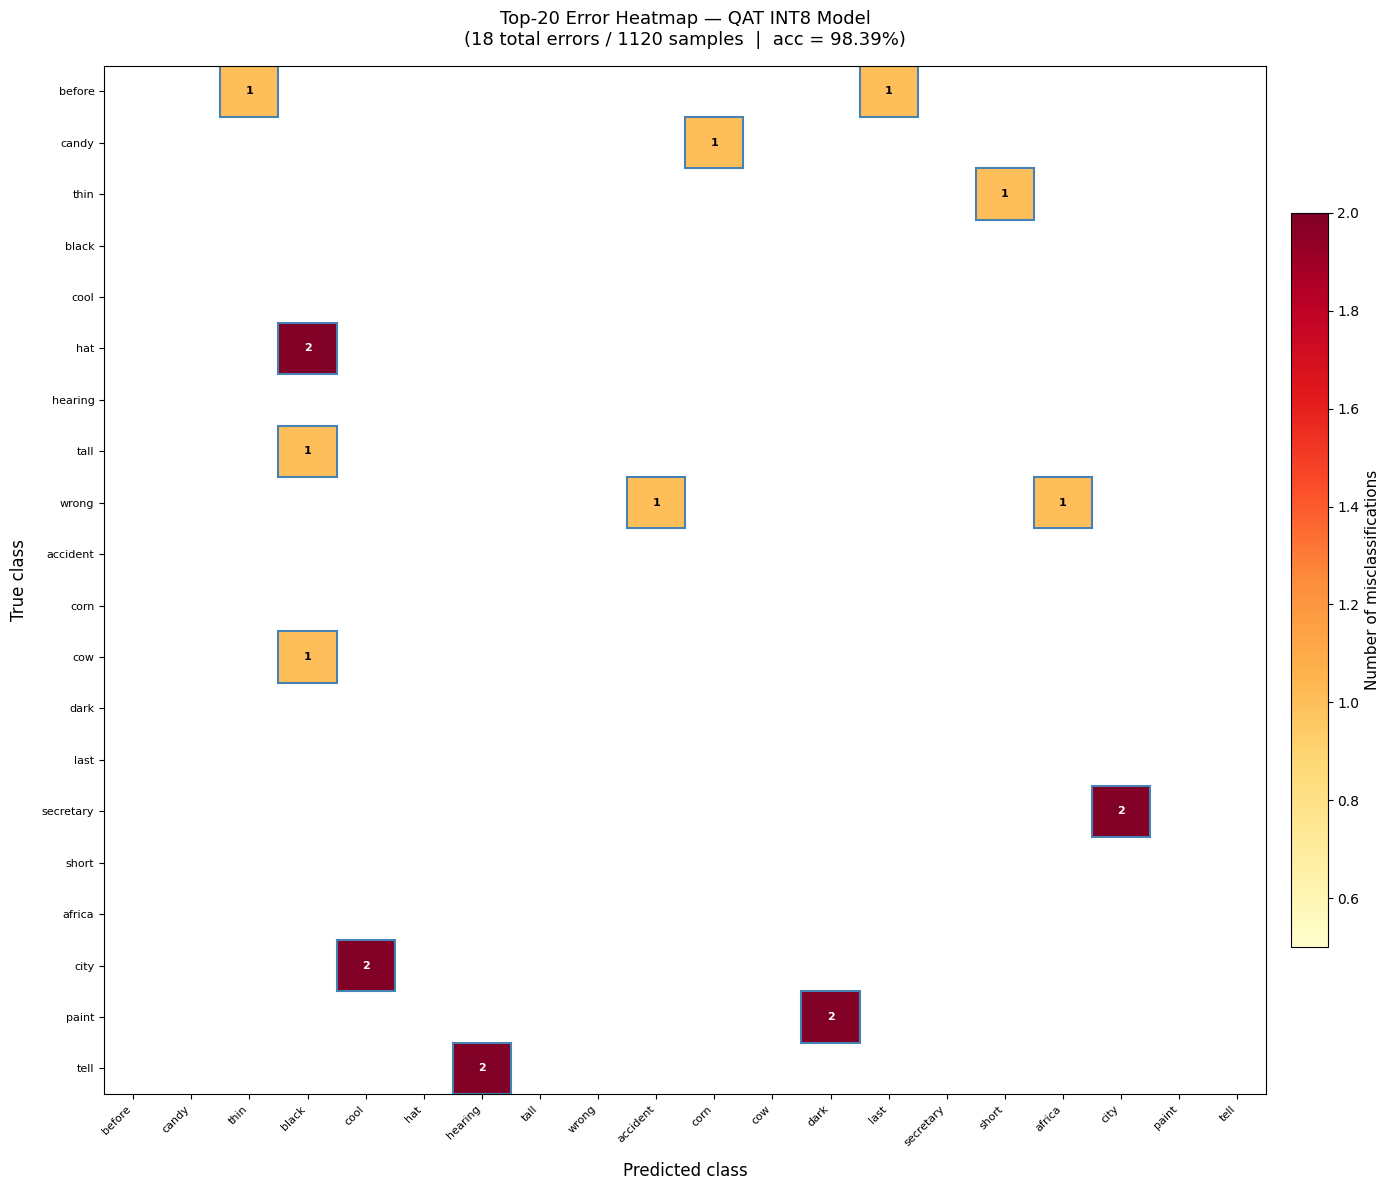


Saved → /kaggle/working/top20_error_heatmap.png

  PER-CLASS ERROR RATE (classes in top-20 errors)
  Class                       Total  Errors    Err %
────────────────────────────────────────────────────────────
  before                         16       2    12.5%  ██████
  candy                          14       1     7.1%  ███
  thin                           18       1     5.6%  ██
  black                          13       0     0.0%  
  cool                           18       0     0.0%  
  hat                            12       2    16.7%  ████████
  hearing                        12       0     0.0%  
  tall                           16       1     6.2%  ███
  wrong                          12       2    16.7%  ████████
  accident                       13       0     0.0%  
  corn                           12       0     0.0%  
  cow                             8       1    12.5%  ██████
  dark                           12       0     0.0%  
  last                           11

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import tensorflow as tf
from collections import Counter

# ── Step 1: Run inference on test set ────────────────────────────────────────
print("Running inference on test set...")

y_true_all = []
y_pred_all = []

for x_batch, y_batch in test_ds:
    preds    = qat_model(x_batch, training=False)
    y_pred_all.extend(np.argmax(preds.numpy(), axis=1))
    y_true_all.extend(np.argmax(y_batch.numpy(), axis=1))

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)

# ── Step 2: Find top 20 most frequent errors ──────────────────────────────────
# An error is a (true_class, predicted_class) pair where true ≠ pred
errors = [(t, p) for t, p in zip(y_true, y_pred) if t != p]

print(f"\nTotal errors   : {len(errors)}")
print(f"Total samples  : {len(y_true)}")
print(f"Error rate     : {len(errors)/len(y_true)*100:.2f}%")

error_counts  = Counter(errors)
top20_errors  = error_counts.most_common(20)

print(f"\nTop 20 most frequent (true → predicted) errors:")
print("─" * 55)
for rank, ((t, p), count) in enumerate(top20_errors, 1):
    t_label = idx_to_label.get(t, str(t))
    p_label = idx_to_label.get(p, str(p))
    print(f"  {rank:2d}. [{count:3d}×]  '{t_label}'  →  '{p_label}'")

# ── Step 3: Extract the unique classes involved in top-20 errors ──────────────
involved_classes = sorted(set(
    cls for pair, _ in top20_errors for cls in pair
))
n = len(involved_classes)
class_labels = [idx_to_label.get(c, str(c)) for c in involved_classes]

# Build a sub-matrix: rows = true class, cols = predicted class
# Only for classes appearing in the top-20 errors
cls_to_idx = {c: i for i, c in enumerate(involved_classes)}
sub_matrix  = np.zeros((n, n), dtype=int)

for (t, p), count in error_counts.items():
    if t in cls_to_idx and p in cls_to_idx:
        sub_matrix[cls_to_idx[t], cls_to_idx[p]] += count

# Zero out the diagonal (correct predictions) so heatmap focuses on errors
np.fill_diagonal(sub_matrix, 0)

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))

# Use a perceptually-uniform colormap; white = 0 errors
cmap = plt.cm.YlOrRd
cmap.set_under("white")   # cells with 0 errors stay white

im = ax.imshow(
    sub_matrix,
    cmap=cmap,
    vmin=0.5,              # anything below 0.5 (i.e. 0) maps to white
    vmax=sub_matrix.max(),
    aspect="auto"
)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Number of misclassifications", fontsize=11)

# Annotate cells with count (only non-zero)
for i in range(n):
    for j in range(n):
        val = sub_matrix[i, j]
        if val > 0:
            text_color = "white" if val > sub_matrix.max() * 0.6 else "black"
            ax.text(j, i, str(val),
                    ha="center", va="center",
                    fontsize=8, fontweight="bold", color=text_color)

# Axis labels
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(class_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(class_labels, fontsize=8)

ax.set_xlabel("Predicted class", fontsize=12, labelpad=10)
ax.set_ylabel("True class",      fontsize=12, labelpad=10)
ax.set_title(
    f"Top-20 Error Heatmap — QAT INT8 Model\n"
    f"({len(errors)} total errors / {len(y_true)} samples  |  "
    f"acc = {(1 - len(errors)/len(y_true))*100:.2f}%)",
    fontsize=13, pad=15
)

# Highlight the top-20 error cells with a bold border
for rank, ((t, p), count) in enumerate(top20_errors):
    if t in cls_to_idx and p in cls_to_idx:
        row = cls_to_idx[t]
        col = cls_to_idx[p]
        rect = plt.Rectangle(
            (col - 0.5, row - 0.5), 1, 1,
            linewidth=1.5, edgecolor="steelblue", facecolor="none"
        )
        ax.add_patch(rect)

plt.tight_layout()
plt.savefig("/kaggle/working/top20_error_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → /kaggle/working/top20_error_heatmap.png")

# ── Step 5: Per-class error rate for the involved classes ─────────────────────
print("\n" + "=" * 60)
print("  PER-CLASS ERROR RATE (classes in top-20 errors)")
print("=" * 60)
print(f"  {'Class':<25s}  {'Total':>6s}  {'Errors':>6s}  {'Err %':>7s}")
print("─" * 60)

for c in involved_classes:
    label      = idx_to_label.get(c, str(c))
    total      = int((y_true == c).sum())
    n_errors   = int(((y_true == c) & (y_pred != c)).sum())
    err_rate   = n_errors / total * 100 if total > 0 else 0
    bar        = "█" * int(err_rate / 2)
    print(f"  {label:<25s}  {total:>6d}  {n_errors:>6d}  {err_rate:>6.1f}%  {bar}")